# Homework 5

# Задача №1 - Можете ли вы отличить сорняки от рассады?

Теперь приступим к задаче классификации на картинках. Реализуйте программу, которая определяет тип рассады на изображении. 

Для того, чтобы определить характерные особенности каждого типа рассады, у вас есть train. Train это папка, в которой картинки уже классифицированы и лежат в соответствующих папках. Исходя из этой информации можете найти признаки, присущие конкретному растению.

Проверка вашего решения будет на происходить на test. В папке test уже нет метки класса для каждой картинки. 

[Ссылка на Яндекс-диск](https://yadi.sk/d/0Zzp0klXT0iRmA), все картинки тут.

Примеры изображений для теста:
<table><tr>
    <td> <img src="https://i.ibb.co/tbqR37m/fhj.png" alt="Drawing" style="width: 200px;"/> </td>
    <td> <img src="https://i.ibb.co/6yL3Wmt/sfg.png" alt="Drawing" style="width: 200px;"/> </td>
    <td> <img src="https://i.ibb.co/pvn7NvF/asd.png" alt="Drawing" style="width: 200px;"/> </td>
</tr></table>

In [116]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from glob import glob
from typing import Any, TypedDict
from matplotlib.axes import Axes
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from typing import List, Dict, Tuple, Any, Optional
from matplotlib.ticker import AutoMinorLocator

In [117]:
def extract_sift_features(img_path: str) -> Optional[np.ndarray]:
    image = cv2.imread(img_path, cv2.IMREAD_COLOR)

    if image is None:
        return None

    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    color_mask = cv2.inRange(hsv, (35, 50, 50), (85, 255, 255))

    gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    masked_gray = cv2.bitwise_and(gray, gray, mask=color_mask)

    sift = cv2.SIFT_create()
    _, desc = sift.detectAndCompute(masked_gray, None)
    return desc


def build_visual_vocabulary(
    image_list: List[str], num_clusters: int, seed: int = 42
) -> KMeans:
    descriptors_collection = []

    for img_file in tqdm(image_list, desc="Extracting SIFT descriptors"):
        desc = extract_sift_features(img_file)
        if desc is not None:
            descriptors_collection.append(desc)
    print()

    all_descriptors = np.vstack(descriptors_collection)

    kmeans_model = KMeans(n_clusters=num_clusters, random_state=seed)
    kmeans_model.fit(all_descriptors)

    return kmeans_model


def compute_feature_vector(
    image_path: str, kmeans_model: KMeans, num_clusters: int
) -> np.ndarray:
    desc = extract_sift_features(image_path)

    if desc is None:
        return np.zeros(num_clusters, dtype=np.float32)

    cluster_indices = kmeans_model.predict(desc)

    histogram, _ = np.histogram(
        cluster_indices, bins=num_clusters, range=(0, num_clusters)
    )
    histogram = histogram.astype(np.float32)

    if histogram.sum() > 0:
        histogram /= histogram.sum()

    return histogram


def load_data(dataset_path: str) -> Tuple[List[str], List[int], List[str]]:
    categories = sorted(os.listdir(dataset_path))
    image_paths = []
    labels = []

    for idx, category in enumerate(categories):
        category_dir = os.path.join(dataset_path, category)
        for img_path in glob(os.path.join(category_dir, "*.png")):
            image_paths.append(img_path)
            labels.append(idx)

    return image_paths, labels, categories


def train_plant_model(
    train_folder: str, cluster_count: int = 100, random_seed: int = 42
) -> Tuple[Pipeline, KMeans, List[str]]:
    print("Loading training images...")
    print()
    train_files, train_labels, classes = load_data(train_folder)

    print("Creating visual vocabulary...")
    print()
    kmeans = build_visual_vocabulary(train_files, cluster_count, random_seed)

    print("Computing feature vectors for training images...")
    print()

    features = []
    for file in tqdm(train_files, desc="Processing training images"):
        fv = compute_feature_vector(file, kmeans, cluster_count)
        features.append(fv)
    print()

    X_train = np.array(features)
    y_train = np.array(train_labels)

    print("Fitting classifier...")
    print()
    clf = Pipeline(
        [
            ("scaler", StandardScaler()),
            ("logreg", LogisticRegression(random_state=random_seed)),
        ]
    )
    clf.fit(X_train, y_train)

    print("Training completed!")
    print()
    return clf, kmeans, classes


def evaluate_plant_model(
    test_folder: str,
    model: Pipeline,
    kmeans: KMeans,
    classes: List[str],
    cluster_count: int,
) -> Tuple[List[Dict[str, Any]], List[int]]:
    test_files = glob(os.path.join(test_folder, "*.png"))
    evaluation_results = []
    predicted_labels = []

    print(f"Evaluating on {len(test_files)} test images...")
    print()

    for file in tqdm(test_files, desc="Processing test images"):
        fv = compute_feature_vector(file, kmeans, cluster_count)
        probabilities = model.predict_proba([fv])[0]

        best_idx = np.argmax(probabilities)
        best_class = classes[best_idx]
        confidence = probabilities[best_idx]

        predicted_labels.append(best_idx)
        evaluation_results.append(
            {
                "image_path": file,
                "predictions": list(zip(classes, probabilities)),
                "top_class": best_class,
                "top_class_idx": best_idx,
                "confidence": confidence,
            }
        )

    return evaluation_results, predicted_labels

In [118]:
train_dir = os.path.join("plants", "train")
test_dir = os.path.join("plants", "test")

feature_size = 100
random_state = 42

y_test = np.array(
    [
        0,
        0,
        1,
        1,
        0,
        0,
        2,
        3,
        1,
        0,
        1,
        1,
        0,
        3,
        2,
        3,
        2,
        3,
        0,
        3,
        2,
        2,
        3,
        1,
        3,
        2,
        2,
        1,
        3,
        3,
        0,
        2,
        0,
        0,
        1,
        2,
        3,
        2,
        1,
        1,
    ]
)

print()
clf, kmeans, classes = train_plant_model(train_dir, feature_size, random_state)


Loading training images...

Creating visual vocabulary...



Extracting SIFT descriptors: 100%|██████████| 20/20 [00:02<00:00,  8.80it/s]



Computing feature vectors for training images...



Processing training images: 100%|██████████| 20/20 [00:02<00:00,  8.61it/s]


Fitting classifier...

Training completed!



In [119]:
print()
test_results, y_pred = evaluate_plant_model(
    test_dir, clf, kmeans, classes, feature_size
)
print()

print("Summary metrics:")
print()

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print()


Evaluating on 40 test images...



Processing test images: 100%|██████████| 40/40 [00:05<00:00,  7.77it/s]


Summary metrics:

Accuracy: 1.0



# Задача №2 - Собери пазл (2.0).

Даны кусочки изображения, ваша задача склеить пазл в исходную картинку. 

Условия:
* Дано исходное изображение для проверки, использовать собранное изображение в самом алгоритме нельзя;
* Картинки имеют друг с другом пересечение;
* После разрезки кусочки пазлов не были повернуты или отражены;
* НЕЛЬЗЯ выбрать опорную картинку для сбора пазла, как это было в homework 3
* В процессе проверки решения пазлы могут быть перемешаны, т.е. порядок пазлов в проверке может отличаться от исходного 

Изображения расположены по [ссылке](https://disk.yandex.ru/d/XtpawH1sV9UDlg).

Примеры изображений:
<img src="puzzle/su_fighter.jpg" alt="Drawing" style="width: 300px;"/>
<table><tr>
    <td> <img src="puzzle/su_fighter_shuffle/0.jpg" alt="Drawing" style="width: 200px;"/> </td>
    <td> <img src="puzzle/su_fighter_shuffle/1.jpg" alt="Drawing" style="width: 200px;"/> </td>
    <td> <img src="puzzle/su_fighter_shuffle/2.jpg" alt="Drawing" style="width: 200px;"/> </td>
    <td> <img src="puzzle/su_fighter_shuffle/3.jpg" alt="Drawing" style="width: 200px;"/> </td>
</tr></table>

In [120]:
def set_grid(
    ax: Axes,
    n_locator: int = 10,
    minor_line_width: float = 0.2,
    major_line_width: float = 0.4,
) -> None:
    ax.xaxis.set_minor_locator(AutoMinorLocator(n_locator))
    ax.yaxis.set_minor_locator(AutoMinorLocator(n_locator))
    ax.grid(which="minor", linestyle="--", linewidth=minor_line_width)
    ax.grid(which="major", linewidth=major_line_width)


def is_rgb_histograms(data: dict) -> bool:
    return isinstance(data, dict) and set(data.keys()) == {"r", "g", "b"}


def verbose_plot(
    to_plot: Any,
    title: str = "",
    x_label: str = "",
    y_label: str = "",
    figure_size: tuple[float, float] = (10, 6),
    is_image: bool = False,
) -> None:
    if to_plot is None or (isinstance(to_plot, np.ndarray) and to_plot.size == 0):
        return

    _, axs = plt.subplots(1, 1, figsize=figure_size)

    axs.set_title(title)
    axs.set_xlabel(x_label)
    axs.set_ylabel(y_label)

    if isinstance(to_plot, dict):
        if is_rgb_histograms(to_plot):
            for color in ("r", "g", "b"):
                axs.plot(to_plot[color], color=color, label=color.upper())
        else:
            for key, value in to_plot.items():
                axs.plot(value, label=key)
        axs.legend()
    else:
        if is_image:
            axs.imshow(to_plot)
            axs.axis("off")
        else:
            axs.plot(to_plot)

    set_grid(axs)
    plt.show()


def puzzle_images(images_paths: list) -> None:
    n_features = 1000
    n_octave_layers = 3
    contrast_threshold = 0.04
    edge_threshold = 8
    sigma = 1.3

    detector = cv2.SIFT_create(
        nfeatures=n_features,
        nOctaveLayers=n_octave_layers,
        contrastThreshold=contrast_threshold,
        edgeThreshold=edge_threshold,
        sigma=sigma,
    )

    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
    flann = cv2.BFMatcher(cv2.NORM_L2, False)
    image_base = cv2.imread(images_paths[0])

    num_images = len(images_paths)
    grid_size = int(np.sqrt(num_images))
    H, W = (image_base.shape[0] * 2 * grid_size,
            image_base.shape[1] * 2 * grid_size)

    final = np.zeros((H, W, 3))
    row_start = H // 2 - image_base.shape[0] // 2
    row_end = H // 2 + image_base.shape[0] // 2
    col_start = W // 2 - image_base.shape[1] // 2
    col_end = W // 2 + image_base.shape[1] // 2
    final[row_start:row_end, col_start:col_end] = image_base / 255
    del image_base

    bases = [[] for _ in range(num_images)]
    candidates = list(range(1, num_images))
    center = [0]
    checked = []
    ratio_thresh = 0.47

    while center:
        i = center.pop()
        loc_image_i = cv2.imread(images_paths[i])

        yrcb_i = cv2.cvtColor(loc_image_i, cv2.COLOR_RGB2YCrCb)
        bright_i = clahe.apply(yrcb_i[:, :, 0])
        yrcb_i[:, :, 0] = bright_i
        loc_image_i = cv2.cvtColor(yrcb_i, cv2.COLOR_YCrCb2RGB)

        keypoints_i, descriptors_i = detector.detectAndCompute(
            loc_image_i, None)

        if descriptors_i is None:
            continue

        while candidates:
            j = candidates.pop()
            checked.append(i)

            loc_image_j = cv2.imread(images_paths[j])

            yrcb_j = cv2.cvtColor(loc_image_j, cv2.COLOR_RGB2YCrCb)
            bright_j = clahe.apply(yrcb_j[:, :, 0])
            yrcb_j[:, :, 0] = bright_j
            loc_image_j = cv2.cvtColor(yrcb_j, cv2.COLOR_YCrCb2RGB)

            keypoints_j, descriptors_j = detector.detectAndCompute(
                loc_image_j, None)

            if descriptors_j is None:
                continue

            raw_matches = flann.knnMatch(
                np.asarray(descriptors_i, np.float32),
                np.asarray(descriptors_j, np.float32),
                k=2,
            )

            good_matches = [
                m
                for m, n in raw_matches
                if len(raw_matches[0]) >= 2 and m.distance < ratio_thresh * n.distance
            ]

            if len(good_matches) >= 3:
                points1 = np.float32(
                    [keypoints_i[match.queryIdx].pt for match in good_matches]
                )
                points2 = np.float32(
                    [keypoints_j[match.trainIdx].pt for match in good_matches]
                )

                mask = np.uint8(
                    cv2.cvtColor(final.astype(np.float32)
                                 * 255, cv2.COLOR_BGR2GRAY)
                    == 0
                )
                mask = cv2.erode(mask, np.ones((3, 3)), iterations=2)
                mask = cv2.dilate(mask, np.ones((3, 3)), iterations=2)

                out_affine = cv2.estimateAffine2D(points2, points1)

                if out_affine[0] is not None:
                    center.append(j)

                    transformed_image = np.zeros((H, W, 3))
                    row_start = H // 2 - loc_image_j.shape[0] // 2
                    row_end = H // 2 + loc_image_j.shape[0] // 2
                    col_start = W // 2 - loc_image_j.shape[1] // 2
                    col_end = W // 2 + loc_image_j.shape[1] // 2
                    transformed_image[row_start:row_end, col_start:col_end] = (
                        loc_image_j / 255
                    )

                    for base in bases[i]:
                        bases[j].append(base)
                        transformed_image = cv2.warpAffine(
                            transformed_image, base, (W, H)
                        )

                    bases[j].append(out_affine[0])

                    transformed_image = cv2.warpAffine(
                        transformed_image, out_affine[0], (W, H)
                    )

                    final += (
                        np.repeat(mask[..., np.newaxis], 3,
                                  axis=-1) * transformed_image
                    )

        candidates = [
            k for k in range(1, num_images) if k not in center and k not in checked
        ]

    verbose_plot(final, is_image=True)


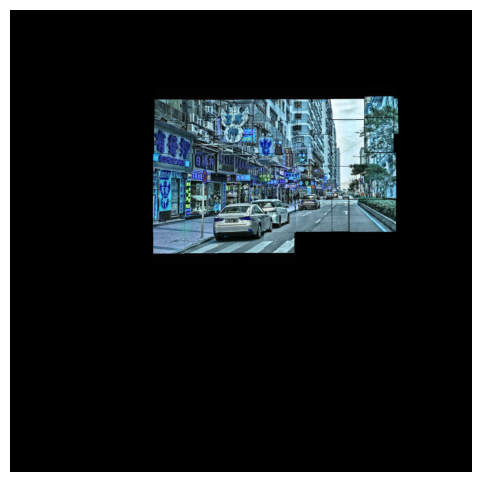

In [121]:
china_shuffle = glob(f"{os.getcwd()}/puzzle/china_shuffle/*")

puzzle_images(china_shuffle)

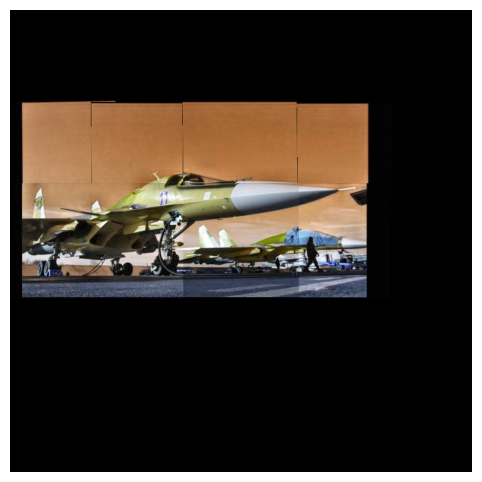

In [122]:
su_fighter_shuffle = glob(f"{os.getcwd()}/puzzle/su_fighter_shuffle/*")

puzzle_images(su_fighter_shuffle)

In [123]:
images_paths = glob(f"{os.getcwd()}/puzzle/home_shuffle/*")

# puzzle_images(images_paths)
# Не работает(((